# MSA 2026 Phase 2 - Part 3: Sale Forecasting from Sales Data

## 1. Load and check the dataset

In [ ]:
import pandas as pd

### Load dataset
transaction_df = pd.read_csv("Sales Data.csv", low_memory=False)

### Check number of rows and columns in each dataset
print("Transaction Dataset: ", transaction_df.shape)
print(transaction_df.columns)


### Display the first five instances.
print("First 5 instances:")
print(transaction_df.head())


### Key statistical measures
numeric_variables = ["Quantity Ordered",  "Price Each", "Month", "Sales", "Hour"]
categorical_variables = ["Order ID", "Product", "Order Date", "Purchase Address", "City"]
print(transaction_df[numeric_variables].describe())

### Correlations between variables
correlation_transaction_df = transaction_df.corr(numeric_only=True)
print(correlation_transaction_df)
sales_corr = correlation_transaction_df["Sales"]
print(sales_corr.sort_values(ascending=False))

### Convert types of variables into numerical values
## Check type of each variable and null values
# Number of non-null values of each variable and its types:
print(transaction_df.info())

# Percentage of missing values in each column
print("Percentage of missing data of each column")
print((transaction_df.isnull().sum() / len(transaction_df) *100).sort_values(ascending=False))

## Convert the Date column to datetime type
transaction_df["Date"] = pd.to_datetime(transaction_df["Order Date"]) 

Transaction Dataset:  (185950, 11)
Index(['Unnamed: 0', 'Order ID', 'Product', 'Quantity Ordered', 'Price Each',
       'Order Date', 'Purchase Address', 'Month', 'Sales', 'City', 'Hour'],
      dtype='str')
First 5 instances:
   Unnamed: 0  Order ID               Product  Quantity Ordered  Price Each  \
0           0    295665    Macbook Pro Laptop                 1     1700.00   
1           1    295666    LG Washing Machine                 1      600.00   
2           2    295667  USB-C Charging Cable                 1       11.95   
3           3    295668      27in FHD Monitor                 1      149.99   
4           4    295669  USB-C Charging Cable                 1       11.95   

            Order Date                        Purchase Address  Month  \
0  2019-12-30 00:01:00  136 Church St, New York City, NY 10001     12   
1  2019-12-29 07:03:00     562 2nd St, New York City, NY 10001     12   
2  2019-12-12 18:21:00    277 Main St, New York City, NY 10001     12   
3  201

## 2. Research Questions

In [51]:
"""### Which month generates the highest revenue?
monthly_sales = transaction_df.groupby("Month")["Sales"].sum().reset_index()
monthly_sales.sort_values("Sales", ascending=False, inplace=True)
print(f"In total, the month generates the highest revenue is {monthly_sales["Month"].iloc[0]} that is ${round(monthly_sales["Sales"].iloc[0])}")

### Which city contributes the most sales?
city_sales =  transaction_df.groupby("City")["Sales"].sum().reset_index(name="Sales")
city_sales.sort_values("Sales", ascending=False, inplace=True)
print(f"In total, The city contributes the most sales is{city_sales["City"].iloc[0]} that is ${round(city_sales["Sales"].iloc[0])}")

### Which products have the highest quantity sold and revenue contribution?
product_sales = transaction_df.groupby("Product")[["Quantity Ordered", "Sales"]].sum().reset_index()
product_sales.sort_values("Quantity Ordered", ascending=False, inplace=True)
print(f"The products have the highest quantity sold is {product_sales["Product"].iloc[0]} ({product_sales["Quantity Ordered"].iloc[0]} sold products) and its revenue contribution is ${round(product_sales["Sales"].iloc[0])}")
"""

### What time of day has the highest order activity?

### Are expensive products sold less frequently?

### Which products are frequently purchased together?

### Can machine learning models predict sales revenue accurately?

### Which features are most important in predicting sales?


'### Which month generates the highest revenue?\nmonthly_sales = transaction_df.groupby("Month")["Sales"].sum().reset_index()\nmonthly_sales.sort_values("Sales", ascending=False, inplace=True)\nprint(f"In total, the month generates the highest revenue is {monthly_sales["Month"].iloc[0]} that is ${round(monthly_sales["Sales"].iloc[0])}")\n\n### Which city contributes the most sales?\ncity_sales =  transaction_df.groupby("City")["Sales"].sum().reset_index(name="Sales")\ncity_sales.sort_values("Sales", ascending=False, inplace=True)\nprint(f"In total, The city contributes the most sales is{city_sales["City"].iloc[0]} that is ${round(city_sales["Sales"].iloc[0])}")\n\n### Which products have the highest quantity sold and revenue contribution?\nproduct_sales = transaction_df.groupby("Product")[["Quantity Ordered", "Sales"]].sum().reset_index()\nproduct_sales.sort_values("Quantity Ordered", ascending=False, inplace=True)\nprint(f"The products have the highest quantity sold is {product_sales[

## 3. Select the feature(s) for the model, and explain the reason

In [ ]:
# write your answer here
# Variables after cleaning that dataset:
print("Columns after cleaning that dataset")
print(adjusted_weather_df.columns)

"""
SELECT:
- MaxTemp: use for training and validation
- Precip: This variable records the precipitation of different days at the stations. Rainy days tend to have 
cooler weather which is very useful information to predict maximum temperature.
- MinTemp: This variable is an independent variable which is very important for maximum temperaure prediction.
The variable is a signal for the model to predict because it shows the minimum level that the temperature of a 
day can reach which means the maximum temperature has to be higher. The strong association between MinTemp and 
MaxTemp is also shown by the correlation which is around 0.88.
- Snowfall: This variable records the amount of snow fall at the given stations. Snow is only occurs in cold 
weather which is very informative to predict the maximum temperature.

NOT SELECT:
- STA: This variable is the station ID for identifier which do not provide useful information related to its 
location or geographic features, such as climate zone, to predict the maximum temperature.
- Date: This variable is the date of the day that they record other variables which also do not provide useful
information to predict the maximum temperature.
- MeanTemp: This variable is a dependent variable which calculated by using MinTemp and MaxTemp (variable that I 
target to predict). This is shown by the correlation between MeanTemp and MaxTemp (~0.97). The model can obviously 
know what the exact MaxTemp values should be when knowing MinTemp and MeanTemp. So including MeanTemp for train models 
can lead to data leakage. 
- MAX, MIN, and MEA: These three variables are MaxTemp, MinTemp, and MeanTemp which are converted into different 
measurements. For example, MAX is MaxTemp in Fahrenheit which means including MAX directly give the model the target 
variable that I am trying to predict. This leads to data leakage, not merely duplicated information.
- Other variables: They are not informative for MaxTemp prediction because:
    + PoorWeather, TSHDSBRSGF have more than 70% of the data missed in their columns
    + SD3, RHN, RHX, RVG, FT, FTI, WTE, ITH, FB, PGT, WindGustSpd, SPD, DR, SND have 95-100% of the data missed
"""

Columns after cleaning that dataset
Index(['STA', 'Date', 'Precip', 'MaxTemp', 'MinTemp', 'MeanTemp', 'Snowfall'], dtype='str')


'\nSELECT:\n- MaxTemp: use for training and validation\n- Precip: This variable records the precipitation of different days at the stations. Rainy days tend to have \ncooler weather which is very useful information to predict maximum temperature.\n- MinTemp: This variable is an independent variable which is very important for maximum temperaure prediction.\nThe variable is a signal for the model to predict because it shows the minimum level that the temperature of a \nday can reach which means the maximum temperature has to be higher. The strong association between MinTemp and \nMaxTemp is also shown by the correlation which is around 0.88.\n- Snowfall: This variable records the amount of snow fall at the given stations. Snow is only occurs in cold \nweather which is very informative to predict the maximum temperature.\n\nNOT SELECT:\n- STA: This variable is the station ID for identifier which do not provide useful information related to its \nlocation or geographic features, such as c

## 4. Split the dataset (70% for training, 30% for testing)

In [15]:
from sklearn.model_selection import train_test_split

# Separate features (X) and labels (y)
x, y = adjusted_weather_df[['Precip', 'MinTemp', 'Snowfall']].values, adjusted_weather_df['MaxTemp'].values

# Split data 70%-30% into training set and test set
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=1)

print (f'Training Set: {x_train.shape[0]} rows\nTest Set: {x_test.shape[0]} rows')

Training Set: 82483 rows
Test Set: 35350 rows


## 5. Choose the algorithm, train and test the model

In [16]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
 
models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(),
    'Decision Tree': DecisionTreeRegressor(random_state=0),
    'Random Forest': RandomForestRegressor(random_state=0),
    'Gradient Boosting': GradientBoostingRegressor(random_state=0),
}

fitted_models = {}
for key, value in models.items():
    fitted_models[key] = value.fit(x_train, y_train)
    print(f"Model trained: {key}")

print(fitted_models)

Model trained: Linear Regression
Model trained: Lasso
Model trained: Decision Tree
Model trained: Random Forest
Model trained: Gradient Boosting
{'Linear Regression': LinearRegression(), 'Lasso': Lasso(), 'Decision Tree': DecisionTreeRegressor(random_state=0), 'Random Forest': RandomForestRegressor(random_state=0), 'Gradient Boosting': GradientBoostingRegressor(random_state=0)}


## 6. Evaluate and Visualize model Performance

               Model                                   Predicted Values  \
0  Gradient Boosting  [32.5538777285225, 30.44687829291999, 31.84187...   
1      Random Forest  [32.55034432748621, 30.626798168059437, 31.872...   
2      Decision Tree  [32.55179615720302, 30.632440475993295, 31.866...   
3  Linear Regression  [33.76124541074298, 32.27570918955577, 31.7813...   
4              Lasso  [33.68759222123805, 32.20419971537081, 31.7104...   

   Mean Error        MSE      RMSE        R2  
0    0.005527  11.887661  3.447849  0.830512  
1    0.014664  12.199286  3.492748  0.826069  
2    0.016601  12.554138  3.543182  0.821010  
3    0.014046  16.196115  4.024440  0.769085  
4    0.012469  16.344065  4.042779  0.766975  


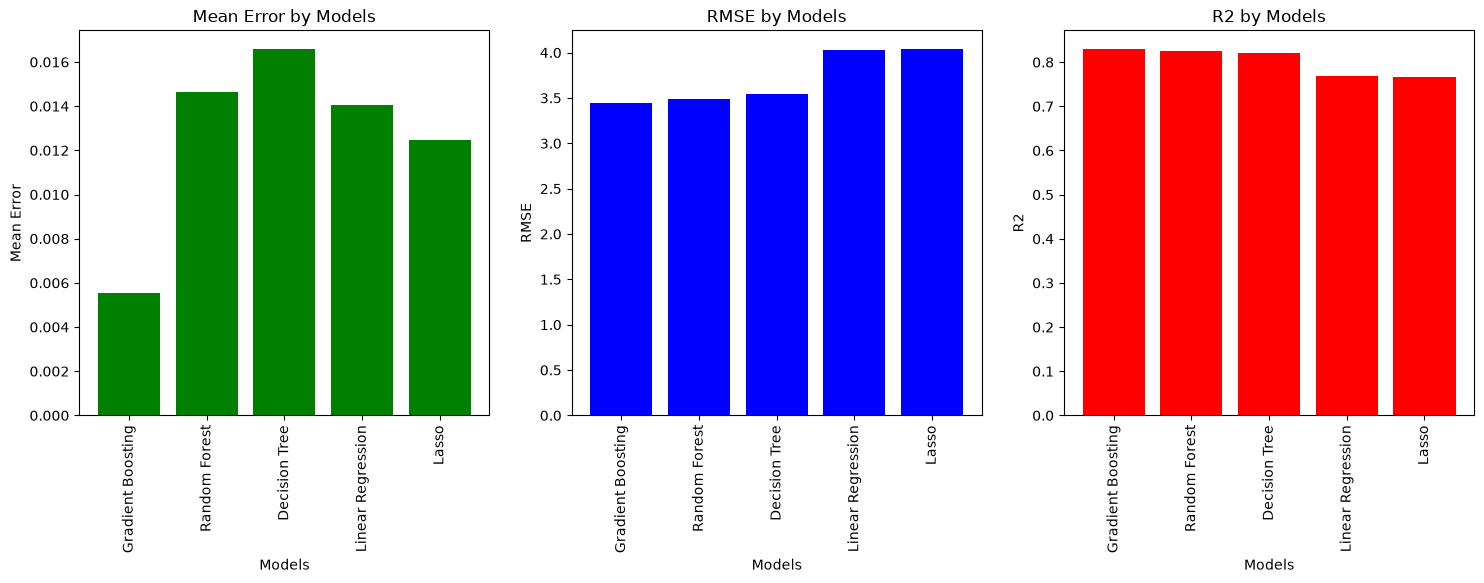

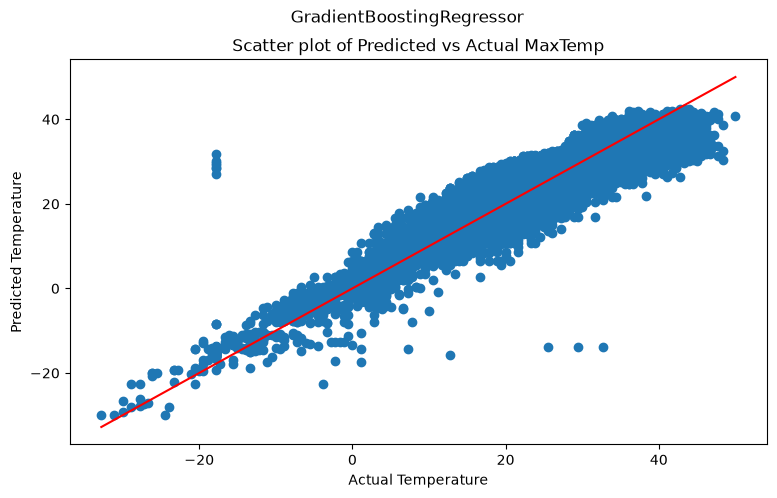

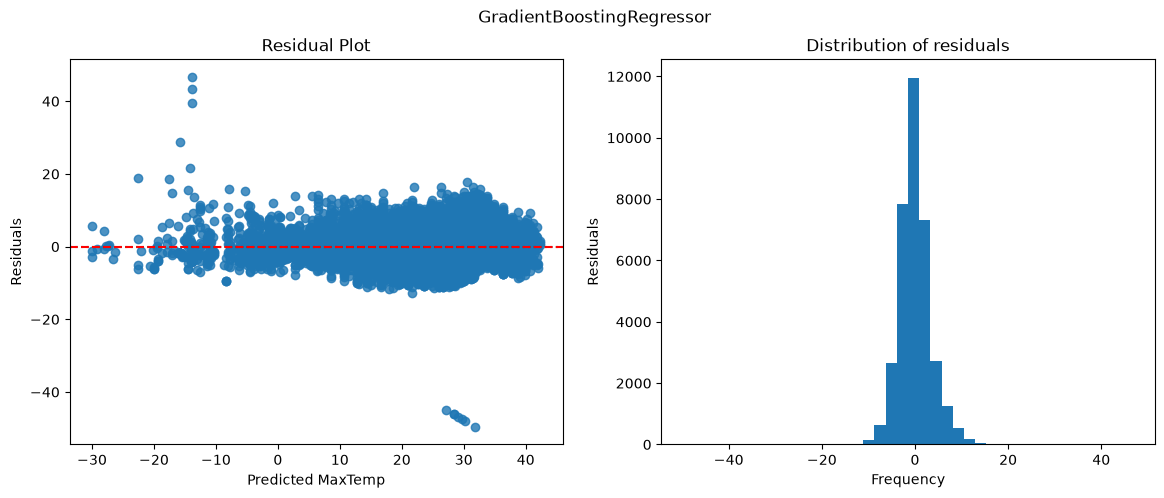

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

predictions = []
for key, prediction in fitted_models.items():
    pred_values  = prediction.predict(x_test)
    mean_errors = np.mean(y_test - pred_values)
    mse = mean_squared_error(y_test, pred_values)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred_values)
    predictions.append(
        {
            'Model': key,
            'Predicted Values' : pred_values,
            'Mean Error': mean_errors,
            'MSE' : mse,
            'RMSE' : rmse,
            'R2' : r2,
        }
    )


prediction_df = pd.DataFrame(predictions).sort_values('R2', ascending=False).reset_index(drop=True)
print(prediction_df)


### Visualisation:
## Measurements of models
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
# Mean Error
ax[0].bar(prediction_df['Model'], prediction_df['Mean Error'], color='green')
ax[0].set_title("Mean Error by Models")
ax[0].set_xlabel("Models")
ax[0].tick_params(axis='x', labelrotation=90)
ax[0].set_ylabel("Mean Error")

# RMSE
ax[1].bar(prediction_df['Model'], prediction_df['RMSE'], color='blue')
ax[1].set_title("RMSE by Models")
ax[1].set_xlabel("Models")
ax[1].tick_params(axis='x', labelrotation=90)
ax[1].set_ylabel("RMSE")

# R2
ax[2].bar(prediction_df['Model'], prediction_df['R2'], color='red')
ax[2].set_title("R2 by Models")
ax[2].set_xlabel("Models")
ax[2].tick_params(axis='x', labelrotation=90)
ax[2].set_ylabel("R2")
plt.show()


## Choose GradientBoostingRegressor:
"""
Based on the average of error between the predicted MaxTemp and actual MaxTemp, Gradient Boosting Model has the
lowest value (0.005527) and is considered to be the most suitable model for the data set to predict MaxTemp out of
5 models.
"""

## Fit the Gradient Boosting model:
predicted_value = prediction_df['Predicted Values'][0]
# Predicted vs Actual MaxTemp:
plt.subplots(figsize=(9,5))
plt.scatter(y_test, predicted_value)
# Get perfect prediction line:
min_equal_value = min(predicted_value.min(), y_test.min())
max_equal_value = max(predicted_value.max(), y_test.max())
prefect_value = [min_equal_value, max_equal_value]
plt.plot(prefect_value, prefect_value, color="red")
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Scatter plot of Predicted vs Actual MaxTemp")
plt.suptitle("GradientBoostingRegressor")
plt.show()

# Residual plot:
error = y_test - predicted_value
fig, ax = plt.subplots(1, 2, figsize=(14,5))
sns.residplot(x=predicted_value, y=error, ax=ax[0])
ax[0].axhline(y=0, linestyle="--", color="red")
ax[0].set_xlabel("Predicted MaxTemp")
ax[0].set_ylabel("Residuals")
ax[0].set_title("Residual Plot")

ax[1].hist(error, bins=40)
ax[1].set_xlabel("Frequency")
ax[1].set_ylabel("Residuals")
ax[1].set_title("Distribution of residuals")
plt.suptitle("GradientBoostingRegressor")
plt.show()





## 7. What is the R² value and RMSE of the model? How these values indicate the model performance?

In [18]:
# write your answer here
# Root Mean Square Error 
print(f'Gradient Boosting Model RMSE: {round(prediction_df['RMSE'][0], 2)}')

# R2
print(f'Gradient Boosting Model R2: {round(prediction_df['R2'][0], 4)}')

"""
RMSE: The RMSE of Gradient Boosting model is 3.45 which indicates incorrect predictions are wrong by around 
3.45 Celsius degree.

R2: The R2 of Gradient Boosting model is 0.8305 which indicates the model explains 83.05% of the variation 
in maximum temperatures of the data set.
"""

Gradient Boosting Model RMSE: 3.45
Gradient Boosting Model R2: 0.8305


'\nRMSE: The RMSE of Gradient Boosting model is 3.45 which indicates incorrect predictions are wrong by around \n3.45 Celsius degree.\n\nR2: The R2 of Gradient Boosting model is 0.8305 which indicates the model explains 83.05% of the variation \nin maximum temperatures of the data set.\n'

## 8. Discuss the model performance based on the plot

In [19]:
# write your answer here
